In [1]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python pycocotools matplotlib

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-fnw6xzqw
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-fnw6xzqw
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=5cf03f21fb7f1edab63f4161ccb3e4db873365d8a72a3c2d96f1cb34b4dc9754
  Stored in directory: /tmp/pip-ephem-wheel-cache-6t9b5wf3/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [12]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2026-02-25 09:04:34--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.51, 3.163.189.108, 3.163.189.14, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.51|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   204MB/s    in 15s     

2026-02-25 09:04:49 (166 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Install detectron2 from source as pre-built wheels for this specific
# PyTorch/CUDA combination might not be available.
# This method usually resolves compatibility issues.
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-i4ly5lqv
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-i4ly5lqv
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 31.9 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7111518 sha2

In [7]:
from google.colab import files
uploaded = files.upload()

Saving kit4.jpg to kit4.jpg


In [8]:
image=cv2.imread("/content/kit4.jpg")

In [6]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import cv2
import matplotlib.pyplot as plt

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file(
        "COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"
    )
)

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4 # Changed from 46 to 4
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/kitchen_output_an/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # confidence threshold
cfg.MODEL.DEVICE = "cuda"  # or "cpu" if no GPU

predictor = DefaultPredictor(cfg)

In [9]:
outputs = predictor(image)
boxes = outputs["instances"].pred_boxes.tensor.cpu().numpy()

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0225 09:02:06.251000 698 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


In [11]:
im = image
outputs = predictor(im)

print(outputs["instances"])

Instances(num_instances=15, image_height=225, image_width=225, fields=[pred_boxes: Boxes(tensor([[  0.0000,  96.6459,  30.1683, 157.0698],
        [ 28.2868,  85.0134,  70.3628, 147.5475],
        [ 96.1638,  77.9215, 117.7813, 129.8240],
        [116.8518,  79.7771, 150.5516, 125.0127],
        [ 74.2263,  78.6109,  94.4706, 130.0924],
        [  0.0000,  57.8446, 202.5961, 100.2290],
        [  4.3895, 187.2509,  17.8633, 225.0000],
        [195.2351, 206.2119, 210.1991, 224.6510],
        [ 12.1565, 104.5333, 219.4341, 222.4812],
        [  0.0000, 184.1510,   7.6989, 225.0000],
        [129.6298, 213.4550, 159.8085, 225.0000],
        [  0.2526,  89.7097, 225.0000, 217.0215],
        [  2.2106, 184.4793,  52.5032, 225.0000],
        [214.0511, 206.3807, 224.6098, 224.9719],
        [101.6572,  66.7369, 217.8645, 112.3852]], device='cuda:0')), scores: tensor([0.9865, 0.9848, 0.9839, 0.9730, 0.9693, 0.9520, 0.7657, 0.6873, 0.6817,
        0.6738, 0.6306, 0.6284, 0.6014, 0.5563, 0.500

In [13]:
import torch
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device="cuda")

predictor_sam = SamPredictor(sam)

In [14]:
import cv2
import numpy as np


outputs = predictor(image)
instances = outputs["instances"].to("cpu")

boxes = instances.pred_boxes.tensor.numpy()
classes = instances.pred_classes.numpy()
scores = instances.scores.numpy()

In [15]:
predictor_sam.set_image(image)

sam_masks = []
sam_classes = []

for i, box in enumerate(boxes):

    input_box = np.array(box)

    masks, scores_sam, logits = predictor_sam.predict(
        box=input_box[None, :],
        multimask_output=False
    )

    sam_masks.append(masks[0])
    sam_classes.append(classes[i])

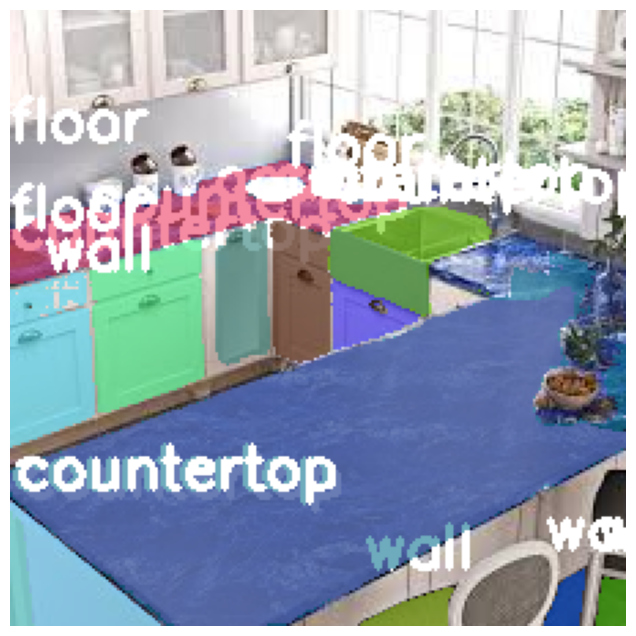

In [17]:
overlay = image.copy()
metadata = MetadataCatalog.get("kitchen_train")

# Define thing_classes for the 'kitchen_train' dataset
# Assuming 4 classes based on cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4
metadata.thing_classes = ["cabinet", "countertop", "floor", "wall"]

for i, mask in enumerate(sam_masks):

    color = np.random.randint(0,255,(3,))
    overlay[mask] = overlay[mask] * 0.4 + color * 0.6

    # Draw class name
    x1, y1, x2, y2 = boxes[i].astype(int)
    class_name = metadata.thing_classes[sam_classes[i]]

    cv2.putText(
        overlay,
        class_name,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255,255,255),
        2
    )

import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(overlay.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

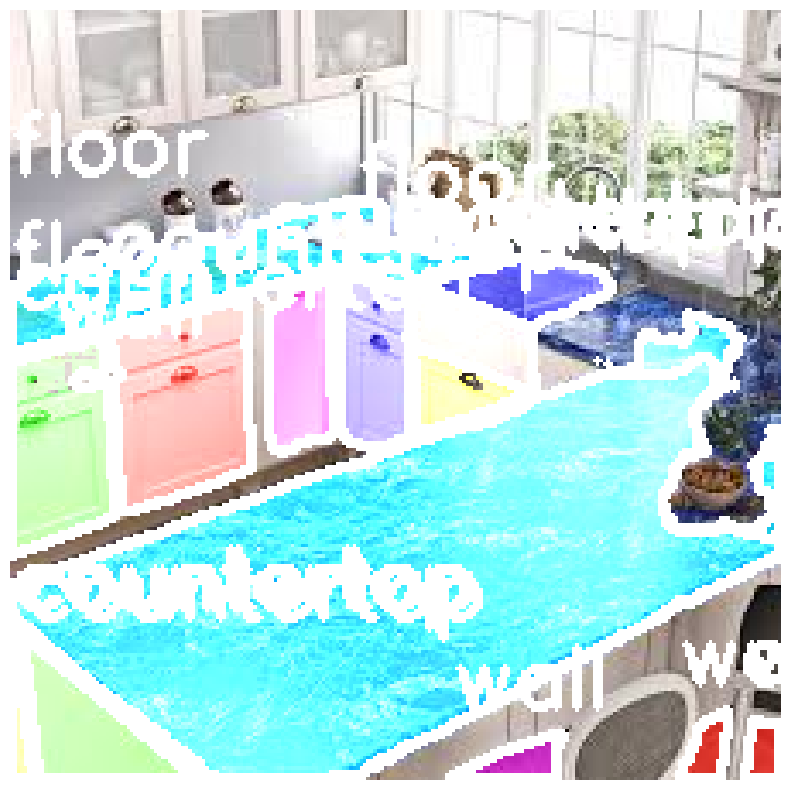

In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

overlay = image.copy()
metadata = MetadataCatalog.get("kitchen_train")

alpha = 0.6  # transparency level

# Predefined bright colors (BGR)
color_palette = [
    (0,255,0),     # Green
    (0,0,255),     # Red
    (255,0,0),     # Blue
    (0,255,255),   # Yellow
    (255,0,255),   # Magenta
    (255,255,0)    # Cyan
]

for i, mask in enumerate(sam_masks):

    color = color_palette[i % len(color_palette)]

    # Create colored mask layer
    colored_mask = np.zeros_like(image, dtype=np.uint8)
    colored_mask[mask] = color

    # Blend mask smoothly
    overlay = cv2.addWeighted(overlay, 1, colored_mask, alpha, 0)

    # Draw mask contour (sharp border)
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(overlay, contours, -1, (255,255,255), 2)

    # Draw class label
    x1, y1, x2, y2 = boxes[i].astype(int)
    class_name = metadata.thing_classes[sam_classes[i]]

    cv2.putText(
        overlay,
        class_name,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255,255,255),
        2
    )

# Show in high resolution
plt.figure(figsize=(14,10))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()